### Project - Smartphone Market Analysis Using Web Scraping

## Business Statement

### To Analyze Smartphone Market data scraped from Flipkart in order to understand brand-wise,Pricing,discounts,rating,RAM,storage,battery capacity,and other key specifications.Identify market trends and customer values oppurtunities and provide data-driven recommendations for better product positioning and pricing decisions 


## Project Objective

### Scrape smartphone data using Requests and BeautifulSoup,clean and transform the data using pandas and regular expressions, perform EDA,answer business questions,generate Business insights and provide recommendations

### 1.Import Libraries

In [119]:
import requests
import re
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd

### 2.Create Headers

In [120]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko)chrome/137.0.0.0 safari 537.36",
    "accept-encoding":"gzip, deflate, br, zstd",
    "content-type":"text/plain;charset=UTF-8"
}                  

### Web Scraping

In [121]:
html = ''
for i in range(1,11):
    url = f'https://www.flipkart.com/search?q=mobiles&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}'
    response = requests.get(url,headers=headers)
    html += response.text
    print(f'Page {i}-->',response.status_code)

Page 1--> 200
Page 2--> 200
Page 3--> 200
Page 4--> 200
Page 5--> 200
Page 6--> 200
Page 7--> 200
Page 8--> 200
Page 9--> 200
Page 10--> 200


In [123]:
soup=BeautifulSoup(html,"html.parser")

In [124]:
products=soup.find_all('div',class_='jIjQ8S')

In [125]:
len(products)

240

### Check One Product

In [126]:
products[0]

<div class="jIjQ8S"><a class="k7wcnx" href="/oneplus-n6-5g-fresh-mint-128-gb/p/itm73a3c7e824695?pid=MOBHZVFJZJS8EE7G&amp;lid=LSTMOBHZVFJZJS8EE7GBZIYTF&amp;marketplace=FLIPKART&amp;q=mobiles&amp;store=tyy%2F4io&amp;srno=s_1_1&amp;otracker=search&amp;otracker1=search&amp;fm=organic&amp;iid=ea129d20-dd8f-4b0e-a0f5-db02dafa4b4b.MOBHZVFJZJS8EE7G.SEARCH&amp;ppt=None&amp;ppn=None&amp;ssid=39lyi9rdsg0000001787298612035&amp;qH=eb4af0bf07c16429&amp;ov_redirect=true" rel="noopener noreferrer" target="_blank"><div class="T6hTMI"><div class="R7Cntx"><div><div class="lWX0_T" style="height:200px;width:200px"><img alt="OnePlus N6 5G (Fresh Mint, 128 GB)" class="UCc1lI" loading="eager" src="https://rukminim2.flixcart.com/image/312/312/xif0q/mobile/y/i/x/n6-5g-n6-oneplus-original-imahzvfjuqp6kz8y.jpeg?q=70"/></div></div></div><div class="b0bTm6"><div class="FJ7IAS"><span class="ZhHnSZ"><label class="BMOCJ3"><input class="UXWKAE" readonly="" type="checkbox"/><div class="ybaCDx"></div></label></span><labe

### Create Empty List

In [127]:
names = []
brands=[]
colors = []
rams = []
storages = []
batteries = []
cameras=[]
prices = []
original_prices=[]
discounts =[]
ratings = []

### Extract Smartphone Details

In [128]:


for product in products:
    name_color = product.find('div',class_='RG5Slk').text

    name = re.findall("(.+) \(",name_color)
    if name:
        names.append(name[0])
        brands.append(name[0].split()[0])
    else:
        names.append(np.nan)
        brands.append(np.nan)

    color = re.findall(r"\((.+)\,",name_color)
    if color:
        colors.append(color[0])
    else:
        colors.append(np.nan)    

    features = product.find('div',class_='CMXw7N').text

    ram = re.findall(r"(\d+) GB RAM",features)
    if ram:
        rams.append(ram[0])
    else:
        rams.append(np.nan) 
        
    storage = re.findall(r"\| (\d+) GB ROM",features)
    if storage:
        storages.append(storage[0])
    else:
        storages.append(np.nan)

    battery = re.findall(r'(\d+) mAh',features)
    if battery:
        batteries.append(battery[0])
    else:
        batteries.append(np.nan)

    camera = re.findall(r'([^|]*Camera)',features)
    if camera:
        cameras.append(camera[0])
    else:
        cameras.append(np.nan)

    price = product.find('div',class_='hZ3P6w DeU9vF')
    if price:
        prices.append(price.text)
    else:
        prices.append(np.nan)

    original_price = product.find('div',class_='kRYCnD gxR4EY')
    if original_price:
        original_prices.append(original_price.text)
    else:
        original_prices.append(np.nan)
        
    discount = product.find('div',class_='HQe8jr'),features
    if discount:
        discounts.append(discount[0])
    else:
        discounts.append(np.nan) 
        
    rating = product.find('div',class_='MKiFS6')   
    if rating:
        ratings.append(rating.text)
    else:
        ratings.append(np.nan)





        

### Check Lengths  

In [129]:
len(names),len(brands),len(colors),len(rams),len(storages),len(batteries),len(cameras),len(prices),len(original_prices),len(discounts),len(ratings)

(240, 240, 240, 240, 240, 240, 240, 240, 240, 240, 240)

### Create DataFrame

In [130]:
df= pd.DataFrame({
                  'Brand':brands,
                  'Name':names,
                  'Color':colors,
                  'RAM':rams,
                  'Storage':storages,
                  'Battery(mAh)':batteries,
                  'Camera':cameras,
                  'Price(in Rs)':prices,
                  'Original Price(in Rs)':original_prices,
                  'Discount':discounts,
                  'Rating':ratings
})

In [131]:
df

,Brand,Name,Color,RAM,Storage,Battery(mAh),Camera,Price(in Rs),Original Price(in Rs),Discount,Rating
0,OnePlus,OnePlus N6 5G,Fresh Mint,4,128,8000,128 GB ROM17.27 cm (6.8 inch) Display50MP Rea...,"₹22,517","₹30,999",[[27% off]],4.1
1,Samsung,Samsung Galaxy F07,Green,4,64,5000,8MP Front Camera,"₹11,999",NaN,None,4.3
2,realme,realme P4 Lite,Beach Gold,4,64,6300,64 GB ROM17.14 cm (6.75 inch) HD+ Display13MP...,"₹12,999","₹24,999",[[48% off]],3.9
3,realme,realme P4 Lite,Sea Blue,4,128,6300,128 GB ROM17.14 cm (6.75 inch) HD+ Display13M...,"₹13,999","₹27,999",[[50% off]],3.9
4,Ai+,Ai+ Pulse 2,Blue,4,128,6000,Expandable Upto 1 TB17.13 cm (6.745 inch) HD+...,"₹11,999","₹15,499",[[22% off]],4.2
...,...,...,...,...,...,...,...,...,...,...,...
235,LAVA,LAVA Virat V1,Nilgiri Blue,4,64,5000,64 GB ROM17.14 cm (6.75 inch) Display13MP Rea...,"₹9,999","₹12,999",[[23% off]],4.2
236,realme,realme P4R 5G,Lavender Glare,6,128,8000,128 GB ROM17.27 cm (6.8 inch) HD+ Display50MP...,"₹21,999","₹39,999",[[45% off]],4.4
237,realme,realme P4R 5G,Lavender Glare,4,128,8000,128 GB ROM17.27 cm (6.8 inch) HD+ Display50MP...,"₹19,999","₹34,999",[[42% off]],4.2
238,realme,realme P4R 5G,Silver Glare,4,128,8000,128 GB ROM17.27 cm (6.8 inch) HD+ Display50MP...,"₹19,999","₹34,999",[[42% off]],4.2


### Data Information

In [132]:
df.to_csv('Flipkart-Smartphone-Market-Analysis.csv')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Brand                  197 non-null    object
 1   Name                   197 non-null    object
 2   Color                  195 non-null    object
 3   RAM                    192 non-null    object
 4   Storage                192 non-null    object
 5   Battery(mAh)           235 non-null    object
 6   Camera                 233 non-null    object
 7   Price(in Rs)           240 non-null    object
 8   Original Price(in Rs)  211 non-null    object
 9   Discount               208 non-null    object
 10  Rating                 224 non-null    object
dtypes: object(11)
memory usage: 20.8+ KB


### Check Missing Values

In [134]:
df.isna().sum()

Brand                    43
Name                     43
Color                    45
RAM                      48
Storage                  48
Battery(mAh)              5
Camera                    7
Price(in Rs)              0
Original Price(in Rs)    29
Discount                 32
Rating                   16
dtype: int64

### Data cleaning

In [135]:
# Removing symbols such as '₹' and 'commas', removing 'Units' such as GB and mAh,
#Converting text value into numeric types like int or float.
# Data cleaning was performed by removing unwanted symbols and units and convert relavent columns

### Convert Numeric Columns

In [136]:
df['RAM'] = df['RAM'].astype('float')
df['Storage'] = df['Storage'].astype('float')
df['Battery(mAh)']=df['Battery(mAh)'].astype('float')

In [137]:
df['Price(in Rs)']=df['Price(in Rs)'].str.replace('₹','',regex=False)
df['Price(in Rs)']=df['Price(in Rs)'].str.replace(',','',regex=False)
df['Price(in Rs)']=df['Price(in Rs)'].astype('float')

In [138]:
df['Original Price(in Rs)']=df['Original Price(in Rs)'].str.replace('₹','',regex=False)
df['Original Price(in Rs)']=df['Original Price(in Rs)'].str.replace(',','',regex=False)
df['Original Price(in Rs)']=df['Original Price(in Rs)'].astype('float')


In [139]:
df['Discount'] = df['Discount'].str.replace('% off','',regex=False)
df['Discount'] = df['Discount'].astype('float')


In [140]:
df['Rating'] = df['Rating'].astype('float')

### Fill Missing Values

In [141]:
# It means replacing empty or unavailable values -NaN,None, or blank cells - with suitable values so the dataset can be analyzed

In [142]:
df['Brand'] = df['Brand'].fillna(df['Brand'].mode()[0])
df['RAM'] = df['RAM'].fillna(df['RAM'].median())
df['Storage'] = df['Storage'].fillna(df['Storage'].median())
df['Battery(mAh)'] = df['Battery(mAh)'].fillna(df['Battery(mAh)'].median())
df['Price(in Rs)'] = df['Price(in Rs)'].fillna(df['Price(in Rs)'].mean())
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())
df['Discount'] = df['Discount'].fillna(df['Discount'].mean())


### Calculate Discount for Records where it is Missing

In [143]:
discount = ((df['Original Price(in Rs)'] - df['Price(in Rs)']) / df ['Original Price(in Rs)']) * 100
df['Discount'] = df['Discount'].fillna(discount)
df['Discount'] = df['Discount'].round(2)


## Check Unique values

In [144]:
df.isna().sum()

Brand                     0
Name                     43
Color                    45
RAM                       0
Storage                   0
Battery(mAh)              0
Camera                    7
Price(in Rs)              0
Original Price(in Rs)    29
Discount                 29
Rating                    0
dtype: int64

In [145]:
df['Brand'].nunique()

15

In [146]:
df['Brand'].unique()

array(['OnePlus', 'Samsung', 'realme', 'Ai+', 'MOTOROLA', 'POCO', 'vivo',
       'REDMI', 'IQOO', 'LAVA', 'Google', 'Apple', 'Vivo', 'Nothing',
       'HMD'], dtype=object)

In [147]:
df['RAM'].unique

<bound method Series.unique of 0      4.0
1      4.0
2      4.0
3      4.0
4      4.0
      ... 
235    4.0
236    6.0
237    4.0
238    4.0
239    8.0
Name: RAM, Length: 240, dtype: float64>

In [148]:
df['Storage'].unique()

array([128.,  64., 256., 512.])

### Check Duplicate Records

In [149]:
df.duplicated().sum()

np.int64(52)

In [150]:
df.drop_duplicates(inplace=True)

In [151]:
df.shape

(188, 11)

### Discriptive Statistics

In [152]:
df.describe()

,RAM,Storage,Battery(mAh),Price(in Rs),Original Price(in Rs),Discount,Rating
count,188.000000,188.000000,188.000000,188.000000,171.000000,171.000000,188.000000
mean,6.180851,143.659574,5571.872340,23128.994681,29036.643275,24.669181,4.221467
std,2.458045,79.802236,1991.359226,21544.718669,23178.064828,13.643554,0.205716
min,3.000000,64.000000,800.000000,549.000000,999.000000,0.020000,3.400000
25%,4.000000,128.000000,5000.000000,13356.000000,16499.000000,14.685000,4.100000
50%,6.000000,128.000000,6000.000000,17999.000000,26499.000000,21.740000,4.200000
75%,8.000000,128.000000,7000.000000,26128.250000,36499.000000,35.525000,4.300000
max,16.000000,512.000000,10001.000000,132900.000000,134900.000000,54.550000,4.700000


### Save Scraped Dataset

In [153]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.to_csv('Smartphone-Market-Analysis.csv',index=False)

In [154]:
df = pd.read_csv('Smartphone-Market-Analysis.csv')

In [155]:
df

,Brand,Name,Color,RAM,Storage,Battery(mAh),Camera,Price(in Rs),Original Price(in Rs),Discount,Rating
0,OnePlus,OnePlus N6 5G,Fresh Mint,4.0,128.0,8000.0,128 GB ROM17.27 cm (6.8 inch) Display50MP Rea...,22517.0,30999.0,27.36,4.1
1,Samsung,Samsung Galaxy F07,Green,4.0,64.0,5000.0,8MP Front Camera,11999.0,NaN,NaN,4.3
2,realme,realme P4 Lite,Beach Gold,4.0,64.0,6300.0,64 GB ROM17.14 cm (6.75 inch) HD+ Display13MP...,12999.0,24999.0,48.00,3.9
3,realme,realme P4 Lite,Sea Blue,4.0,128.0,6300.0,128 GB ROM17.14 cm (6.75 inch) HD+ Display13M...,13999.0,27999.0,50.00,3.9
4,Ai+,Ai+ Pulse 2,Blue,4.0,128.0,6000.0,Expandable Upto 1 TB17.13 cm (6.745 inch) HD+...,11999.0,15499.0,22.58,4.2
...,...,...,...,...,...,...,...,...,...,...,...
183,Nothing,Nothing Phone (4b),4b) (Black,8.0,128.0,6000.0,16MP Front Camera,34999.0,54999.0,36.36,4.4
184,Samsung,Samsung Galaxy S25 5G,Icyblue,12.0,256.0,4000.0,12MP Front Camera,79999.0,80999.0,1.23,4.6
185,realme,realme P4R 5G,Lavender Glare,6.0,128.0,8000.0,128 GB ROM17.27 cm (6.8 inch) HD+ Display50MP...,21999.0,39999.0,45.00,4.4
186,realme,realme P4R 5G,Lavender Glare,4.0,128.0,8000.0,128 GB ROM17.27 cm (6.8 inch) HD+ Display50MP...,19999.0,34999.0,42.86,4.2


### Exploratary Analysis

#### Brand Wise Pricing

In [156]:
brand_price = df.groupby('Brand')['Price(in Rs)'].mean().sort_values(ascending=False)
brand_price.head(15)

Brand
Apple       103150.000000
Google       89999.000000
IQOO         41940.666667
vivo         37544.454545
Nothing      34999.000000
OnePlus      31220.777778
MOTOROLA     26408.090909
Samsung      24807.360000
REDMI        21060.307692
POCO         18655.250000
Vivo         16999.000000
HMD          15999.000000
Ai+          14735.842105
realme       10159.528302
LAVA          9332.333333
Name: Price(in Rs), dtype: float64

In [157]:
import matplotlib.pyplot as plt

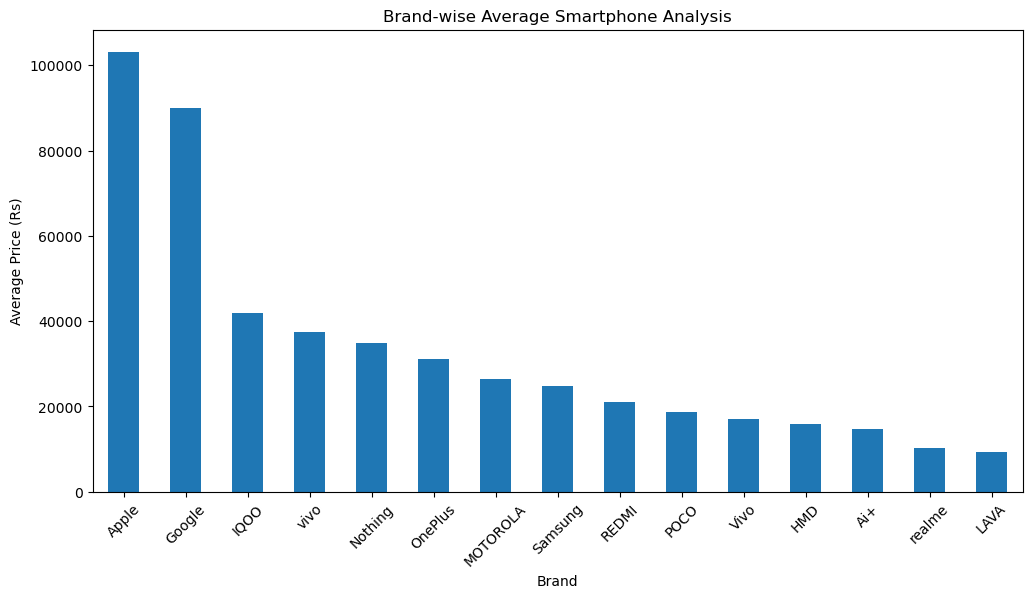

In [158]:
brand_price.head(15).plot(kind='bar',figsize=(12,6))
plt.title('Brand-wise Average Smartphone Analysis')
plt.xlabel('Brand')
plt.ylabel('Average Price (Rs)')
plt.xticks(rotation=45)
plt.show()


### RAM vs PRICE

In [159]:
ram_price = df.groupby('RAM')['Price(in Rs)'].mean()
ram_price

RAM
3.0     10499.000000
4.0     15439.470588
6.0     18036.114754
8.0     29671.815789
12.0    60227.500000
16.0    64999.000000
Name: Price(in Rs), dtype: float64

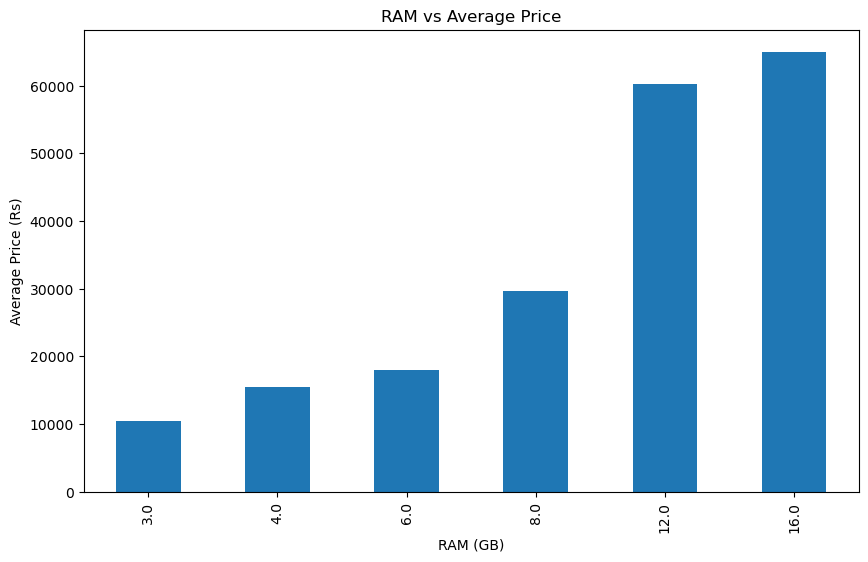

In [160]:
ram_price.plot(kind='bar',figsize=(10,6))
plt.title('RAM vs Average Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Average Price (Rs)')
plt.show()


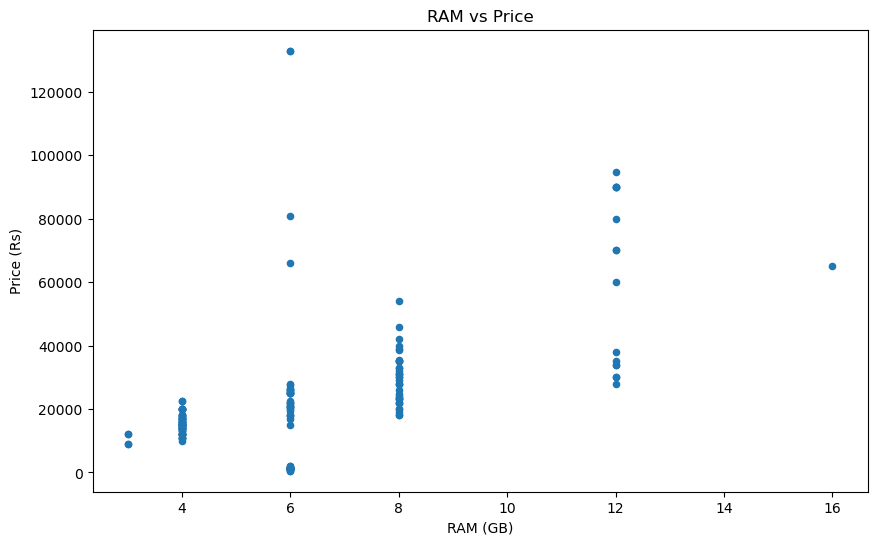

In [161]:
df.plot(x = 'RAM', y = 'Price(in Rs)',kind='scatter',figsize=(10,6))
plt.title('RAM vs Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Rs)')
plt.show()
                                                             

### Storage Comparision

In [162]:
storage_price = df.groupby('Storage')['Price(in Rs)'].mean()
storage_price


Storage
64.0     13768.236842
128.0    19120.448276
256.0    45469.666667
512.0    60749.000000
Name: Price(in Rs), dtype: float64

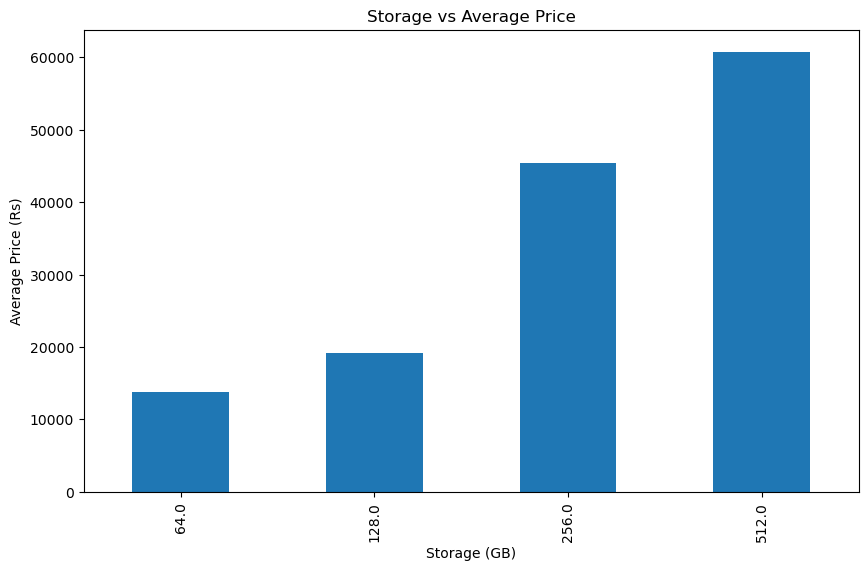

In [163]:
storage_price.plot(kind='bar',figsize=(10,6))
plt.title('Storage vs Average Price')
plt.xlabel('Storage (GB)')
plt.ylabel('Average Price (Rs)')
plt.show()

In [164]:
brand_battery = df.groupby('Brand')['Battery(mAh)'].mean().sort_values(ascending=False)
brand_battery.head(15)

Brand
OnePlus     7888.888889
IQOO        7266.666667
vivo        6736.363636
MOTOROLA    6436.363636
POCO        6295.000000
Ai+         6000.000000
Apple       6000.000000
HMD         6000.000000
Nothing     6000.000000
Vivo        6000.000000
REDMI       5984.615385
Samsung     5240.000000
LAVA        5000.000000
Google      4985.000000
realme      4161.358491
Name: Battery(mAh), dtype: float64

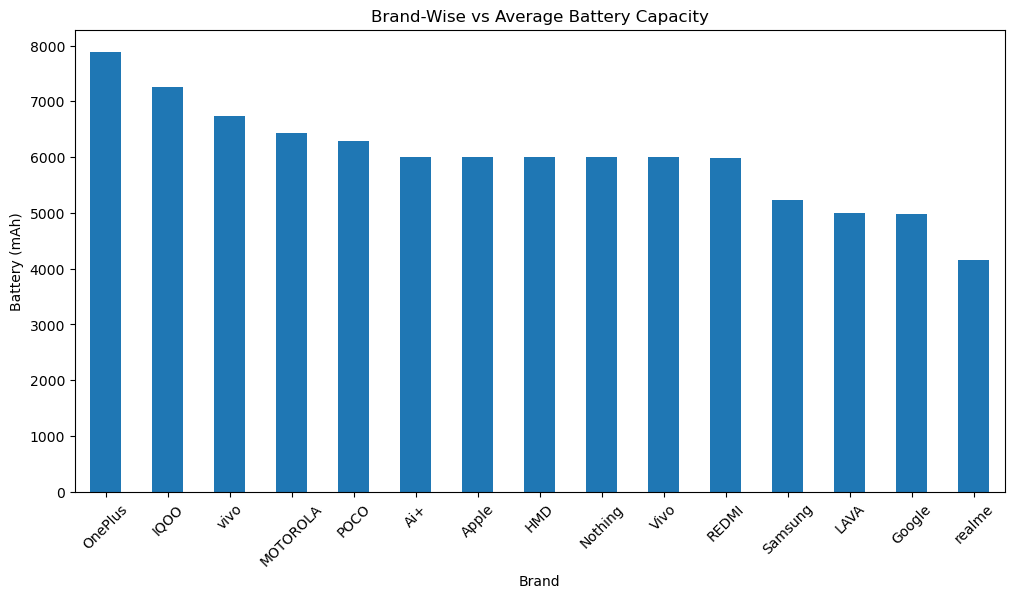

In [165]:
brand_battery.head(15).plot(kind='bar',figsize=(12,6))
plt.title('Brand-Wise vs Average Battery Capacity')
plt.xlabel('Brand')
plt.ylabel('Battery (mAh)')
plt.xticks(rotation=45)
plt.show()

### Discount Analysis

In [166]:
brand_discount = df.groupby('Brand')['Discount'].mean().sort_values(ascending=False)
brand_discount.head(15)

Brand
Vivo        39.290000
Nothing     36.360000
realme      32.120600
POCO        31.692667
MOTOROLA    28.330000
REDMI       25.346154
LAVA        22.186667
vivo        21.839091
Ai+         18.220714
OnePlus     17.712222
HMD         15.835000
Samsung     14.290417
IQOO         3.640000
Apple        2.772500
Google            NaN
Name: Discount, dtype: float64

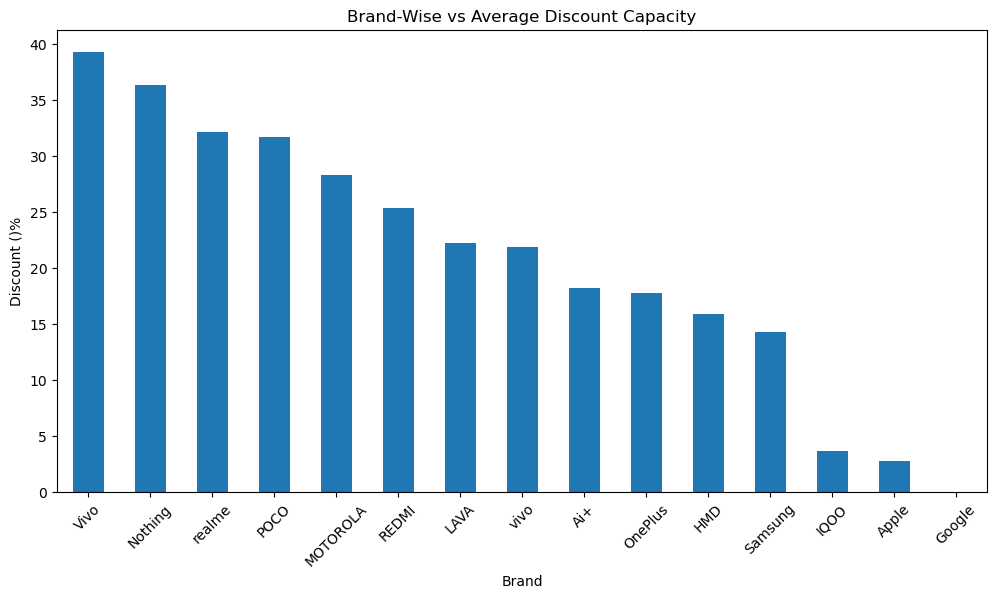

In [167]:
brand_discount.head(15).plot(kind='bar',figsize=(12,6))
plt.title('Brand-Wise vs Average Discount Capacity')
plt.xlabel('Brand')
plt.ylabel('Discount ()%')
plt.xticks(rotation=45)
plt.show()

### Rating Analysis

In [168]:
brand_rating = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)
brand_rating.head(15)

Brand
Apple       4.650000
HMD         4.500000
IQOO        4.500000
vivo        4.427273
Nothing     4.400000
OnePlus     4.355556
Vivo        4.300000
MOTOROLA    4.277273
Samsung     4.244000
Ai+         4.221053
Google      4.208929
REDMI       4.176923
POCO        4.143750
LAVA        4.133333
realme      4.094340
Name: Rating, dtype: float64

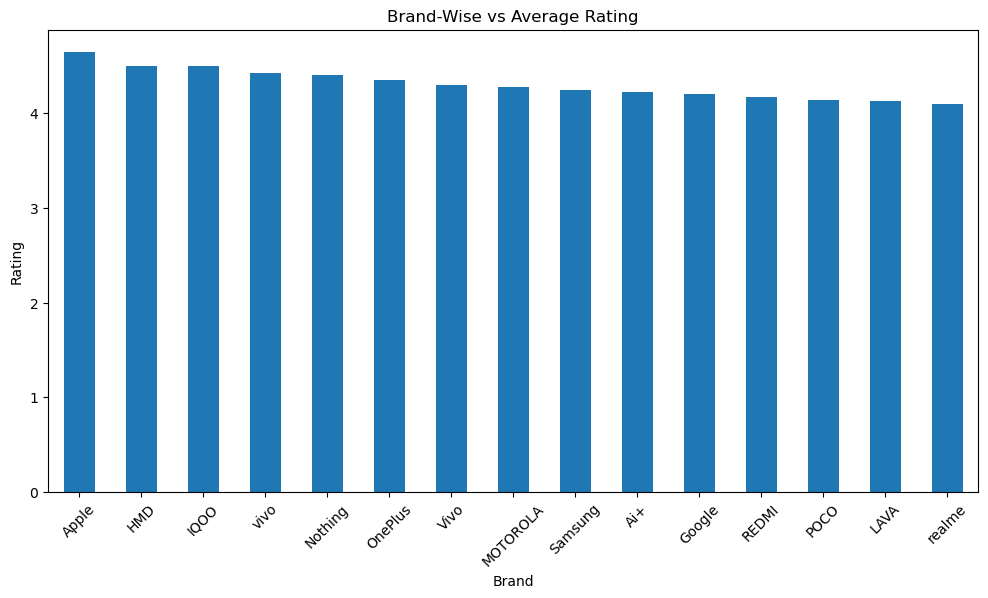

In [169]:
brand_rating.head(15).plot(kind='bar',figsize=(12,6))
plt.title('Brand-Wise vs Average Rating')
plt.xlabel('Brand')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show()

### Price Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

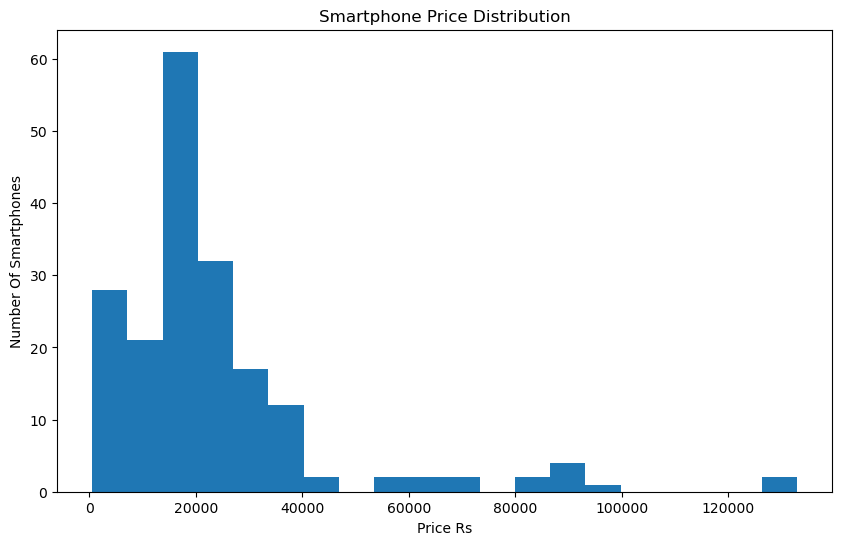

In [170]:
df['Price(in Rs)'].plot(kind='hist',bins=20,figsize=(10,6))
plt.title('Smartphone Price Distribution')
plt.xlabel('Price Rs')
plt.ylabel('Number Of Smartphones')
plt.show

### Rating Distribution

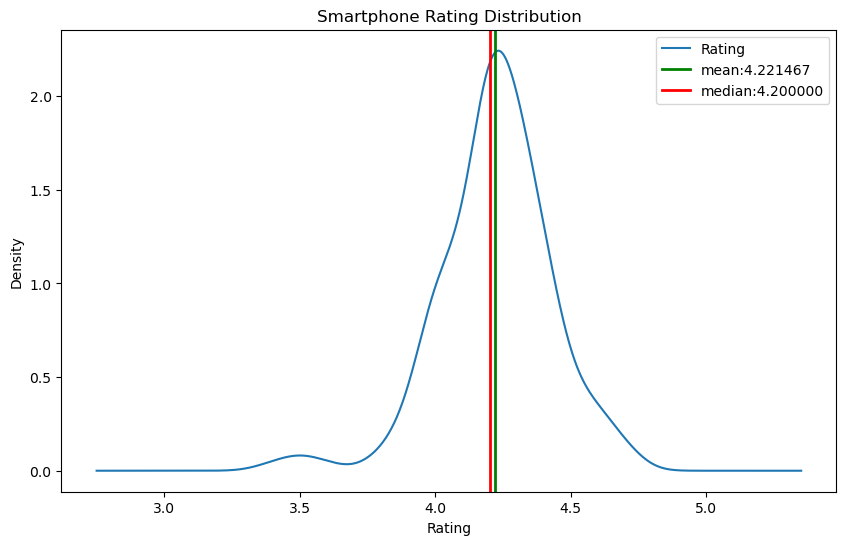

In [171]:
df['Rating'].plot(kind='kde',figsize=(10,6))
plt.axvline(df['Rating'].mean(),color='green',linewidth =2, label=f"mean:{df['Rating'].mean():2f}")
plt.axvline(df['Rating'].median(),color='red',linewidth =2, label=f"median:{df['Rating'].median():2f}")
plt.title('Smartphone Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.show()

### Battery vs Price

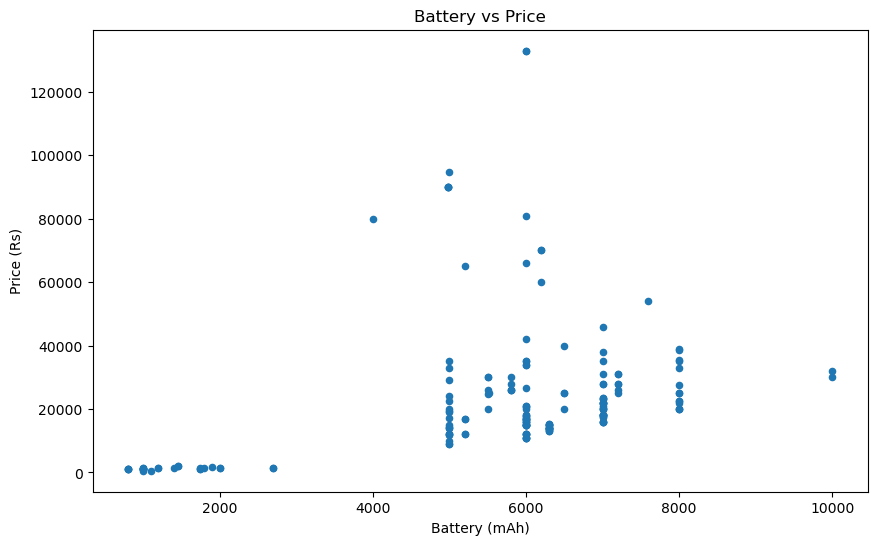

In [172]:
df.plot(x='Battery(mAh)',y='Price(in Rs)',kind ='scatter',figsize=(10,6))
plt.title('Battery vs Price')
plt.xlabel('Battery (mAh)')
plt.ylabel('Price (Rs)')
plt.show()

### Rating Vs Price

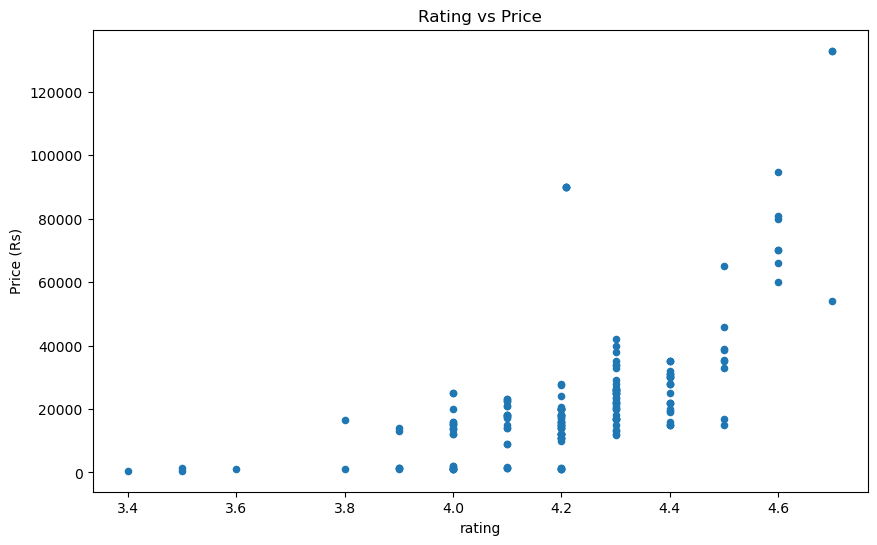

In [173]:
df.plot(x='Rating',y='Price(in Rs)',kind ='scatter',figsize=(10,6))
plt.title('Rating vs Price')
plt.xlabel('rating')
plt.ylabel('Price (Rs)')
plt.show()

### Correlation Analysis

In [174]:
correlation = df[['Price(in Rs)','Discount','Rating','RAM','Storage','Battery(mAh)']].corr()
correlation

,Price(in Rs),Discount,Rating,RAM,Storage,Battery(mAh)
Price(in Rs),1.000000,-0.250969,0.607411,0.573026,0.517361,0.338717
Discount,-0.250969,1.000000,-0.327529,-0.146298,-0.079233,0.117695
Rating,0.607411,-0.327529,1.000000,0.373150,0.345735,0.488006
RAM,0.573026,-0.146298,0.373150,1.000000,0.795050,0.016606
Storage,0.517361,-0.079233,0.345735,0.795050,1.000000,0.085448
Battery(mAh),0.338717,0.117695,0.488006,0.016606,0.085448,1.000000


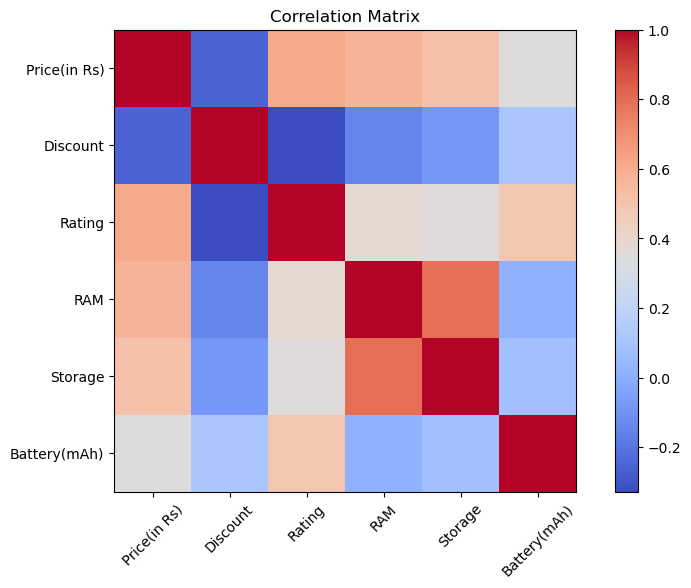

In [175]:
plt.figure(figsize=(10,6))
plt.imshow(correlation,cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(correlation.columns)),correlation.columns,rotation=45)
plt.yticks(range(len(correlation.columns)),correlation.columns)
plt.title('Correlation Matrix')
plt.show()

### Business Questions And Answers

### Questions

#### 1.Which storage category has the highest average price?

In [176]:
storage_price = df.groupby('Storage')['Price(in Rs)'].mean().sort_values(ascending=False)
print('Storage with highest average price:',storage_price.index[0])
print('Average Price:',storage_price.iloc[0])

Storage with highest average price: 512.0
Average Price: 60749.0


#### 2.Which brand provides the highest average discount?

In [177]:
brand_discount = df.groupby('Brand')['Discount'].mean().sort_values(ascending=False)
print('Brand with highest average discount:',brand_discount.index[0])
print('Average discount:',brand_discount.iloc[0])

Brand with highest average discount: Vivo
Average discount: 39.29


#### 3.Which brand has highest rating?

In [178]:
brand_rating = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)
print("Brand with highest average rating:",brand_rating.index[0])
print('Average rating:',brand_rating.iloc[0])

Brand with highest average rating: Apple
Average rating: 4.65


#### 4.which brand has the highest average battery capacity

In [179]:
brand_battery = df.groupby('Brand')['Battery(mAh)'].mean().sort_values(ascending=False)
print("Brand with highest average battery:",brand_battery.index[0])
print('Average battery:',brand_battery.iloc[0])

Brand with highest average battery: OnePlus
Average battery: 7888.888888888889


In [180]:
ram_price = df.groupby('RAM')['Price(in Rs)'].mean()
print("ram with highest average price:",ram_price.index[0])
print('Average price:',ram_price.iloc[0])

ram with highest average price: 3.0
Average price: 10499.0


#### 6.Does higher RAM correspond to higher smartphone price?

In [181]:
ram_price_correlation = df['RAM'].corr(df['Price(in Rs)'])
print('Correlation between RAM and Price:',ram_price_correlation)

Correlation between RAM and Price: 0.5730258461308521


#### 7. Which feature has the strongest positive relationship with price?


In [182]:
price_correlation = df[['Price(in Rs)','Discount','Rating','RAM','Storage','Battery(mAh)']].corr()['Price(in Rs)'].sort_values(ascending=False)
price_correlation

Price(in Rs)    1.000000
Rating          0.607411
RAM             0.573026
Storage         0.517361
Battery(mAh)    0.338717
Discount       -0.250969
Name: Price(in Rs), dtype: float64

#### 8.Which are the top smartphones based on features?

In [183]:
top_smartphones = df.sort_values(['Rating','RAM','Storage','Battery(mAh)'],ascending=False)
top_smartphones[['Brand','Name','Rating','RAM','Price(in Rs)','Storage','Battery(mAh)','Discount']].head(10)

,Brand,Name,Rating,RAM,Price(in Rs),Storage,Battery(mAh),Discount
95,IQOO,IQOO 15R 5G,4.7,8.0,53990.0,256.0,7600.0,0.02
158,Apple,Apple iPhone 17 Pro,4.7,6.0,132900.0,128.0,6000.0,1.48
179,Apple,Apple iPhone 17 Pro,4.7,6.0,132900.0,128.0,6000.0,1.48
61,vivo,vivo X200T,4.6,12.0,69999.0,512.0,6200.0,20.45
172,vivo,vivo X200T,4.6,12.0,69999.0,512.0,6200.0,20.45
170,vivo,vivo X200T,4.6,12.0,59999.0,256.0,6200.0,25.00
181,Samsung,Samsung S25 Ultra 5G,4.6,12.0,94655.0,256.0,5000.0,27.19
184,Samsung,Samsung Galaxy S25 5G,4.6,12.0,79999.0,256.0,4000.0,1.23
73,Apple,Apple iPhone 16,4.6,6.0,65900.0,128.0,6000.0,5.72
75,Apple,Apple iPhone 17,4.6,6.0,80900.0,128.0,6000.0,2.41


### Business Insights

### Business Recomendations